In [1]:
import os
os.environ["OMP_NUM_THREADS"] = "4"
os.environ["MKL_NUM_THREADS"] = "4"

import warnings
warnings.filterwarnings("ignore")

In [2]:
import seaborn as sns
from sklearn.datasets import make_blobs

In [3]:
X, y = make_blobs(
    n_samples=1000,
    n_features=2,
    centers=4,
    random_state=42
)

<Axes: >

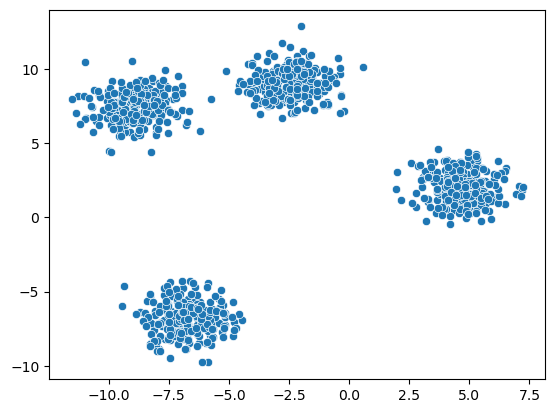

In [4]:
# Visualize
sns.scatterplot(x=X[:, 0], y=X[:, 1])

In [5]:
# K-Means Clustering
from sklearn.cluster import KMeans

In [6]:
K = 4

kmeans = KMeans(
    n_clusters=K,
    random_state=42,
    n_init='auto'
)

In [7]:
labels = kmeans.fit_predict(X)
# label = cluster number

<Axes: >

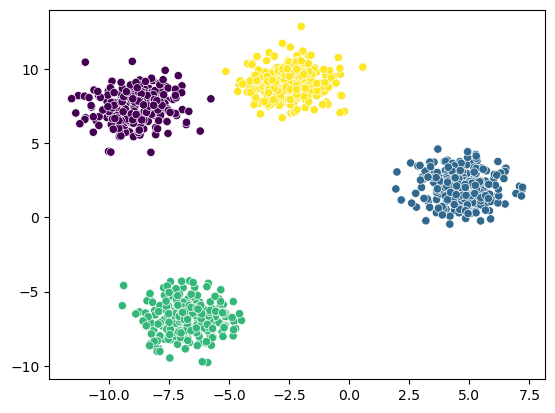

In [8]:
sns.scatterplot(x=X[:, 0], y=X[:, 1], c=labels)

## finding the optimal value of k using elbow method

In [9]:
# Elbow Method

wcss = []
for k in range(1, 21):
    kmeans = KMeans(n_clusters=k,n_init=1)
    kmeans.fit_predict(X)
    wcss.append(kmeans.inertia_)
    

<Axes: >

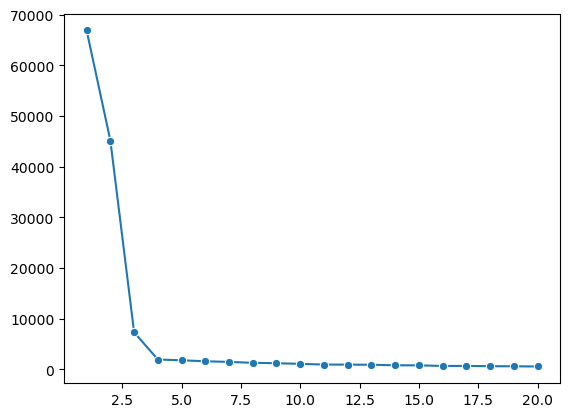

In [10]:
sns.lineplot(x=range(1, 21), y=wcss, marker='o')

### here in the above graph at k=4 we get the stable line plot so we choose it as the optimal k value

In [11]:
from kneed import KneeLocator

In [12]:
knee = KneeLocator(range(1, 21), wcss, curve="convex", direction="decreasing")

In [13]:
print("optimal K = ", knee.elbow)

optimal K =  4


## Finding the value of k using silhouette method

In [14]:
from sklearn.metrics import silhouette_score

In [15]:
ss = []

for k in range(2, 21):
    kmeans = KMeans(n_clusters=k,n_init=2)
    labels = kmeans.fit_predict(X)
    score = silhouette_score(X, labels)

    ss.append(score)

<Axes: >

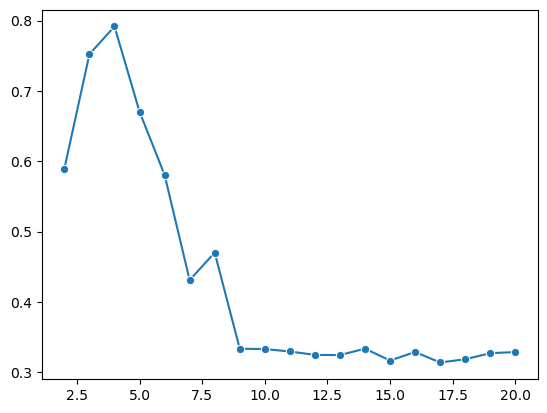

In [16]:
# plot - K & ss

sns.lineplot(x=range(2, 21), y=ss, marker='o')

### Here in the above graph we get the higher silhouette score at k=4 so we choose this k=4 value as optimal k value

In [17]:
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
import pandas as pd

In [18]:
iris = load_iris()

In [19]:
X = iris.data
y = iris.target

In [20]:
X.shape

(150, 4)

<Axes: >

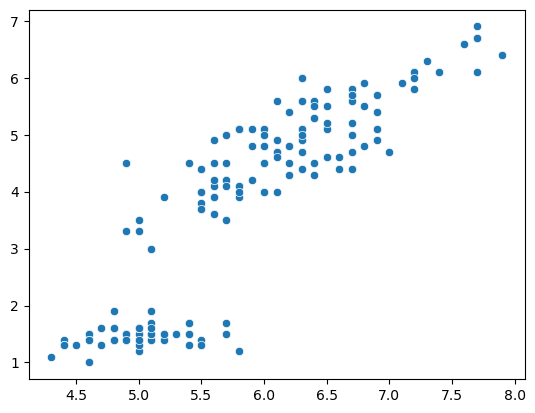

In [21]:
# Visualize
sns.scatterplot(x=X[:,0], y=X[:,2])

In [22]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [23]:
# optional - dimensionality reduciton using PCA
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

pca_data = pca.fit_transform(X_scaled)


In [24]:
# Elbow method
wcss = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k)
    kmeans.fit(pca_data)
    wcss.append(kmeans.inertia_)

<Axes: >

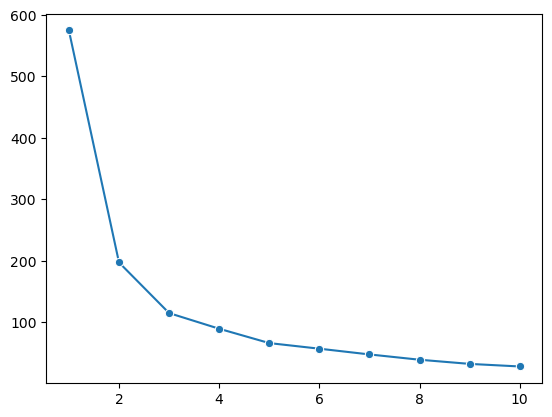

In [25]:
sns.lineplot(x=range(1, 11), y=wcss, marker='o')

<Axes: >

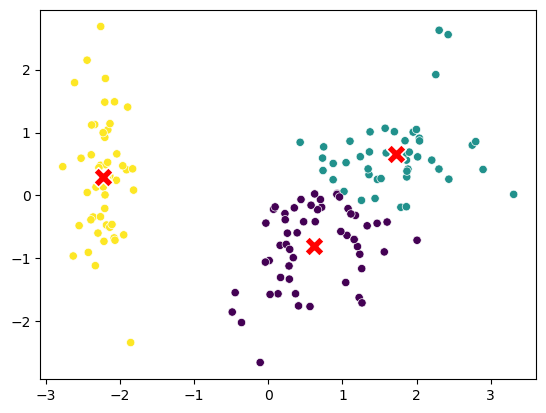

In [26]:
# KMeans

kmeans = KMeans(n_clusters=3, random_state=10)
labels = kmeans.fit_predict(pca_data)

sns.scatterplot(x=pca_data[:, 0], y=pca_data[:,1], c=labels)
sns.scatterplot(x=kmeans.cluster_centers_[:, 0], y=kmeans.cluster_centers_[:, 1], marker="X", c="red", s=200)